In [53]:
# Import required libraries
%reset -f
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.ticker as ticker
import os

In [ ]:
# SYMMETRY CHECK: Read 2 CSV files and flip second one horizontally (across X axis)
# Configuration for symmetry check
sym_folder1 = '../30/sim/30_Re_100'  # Folder for first file
sym_file1 = 'SIM_S_Pos03_Re100_B0001_T.csv'  # First file

sym_folder2 = '../30/sim/30_Re_100'  # Folder for second file
sym_file2 = 'SIM_S_Pos05_Re100_B0001_T.csv'  # Second file (will be flipped)
output_dir = '../Plots/'+ 'symmetry_check_100'  # Output folder for symmetry check plots
pos = 3

file1_label = 'Pos3'
file2_label = 'Pos5'
# Z-heights for line plots (in meters)
z_min_sym = 0.180
z_max_sym = 0.236
z_step_sym = 0.015


n_arrows = 14
# Add constant offsets to velocity components (set to 0 for no offset)
z_velocity_offset = 0.0   # Constant term to add to Z-velocity [m/s]    #3 = 0.05;40_1:015, 40_3:0, Ire_1:0.02 ir_3:0.1

In [55]:
# Automatically extract position number from filename
import re
pos_match = re.search(r'Pos(\d+)', sym_file1)
if pos_match:
    pos = int(pos_match.group(1))
    print(f"Automatically detected Position: {pos}")
else:
    pos = 1  # Default fallback
    print(f"Could not detect position from filename, using default: {pos}")


# File paths
file2_path = sym_folder2 + '/' + sym_file2 # Experimental filename
file1 = sym_file1  # Simulation filename
file1_path = sym_folder1 + '/' + file1

# Plot settings

file_type='aver'
#file_type='inst'

axis_1 = 'Points_0'
axis_2 = 'Points_2'

plot_type = 'horizontal'
#plot_type = 'vertical'

label1 = "simulation"
label2 = "experiment"

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

Could not detect position from filename, using default: 1


In [56]:
# Define both normalization functions
def normalize_x_axis(df):
    """Normalize Points_0 (x-axis) to range [0,1]"""
    df = df.copy()
    x_min = df['Points_0'].min()
    x_max = df['Points_0'].max()
    df['Points_0_normalized'] = (df['Points_0'] - x_min) / (x_max - x_min)
    return df
def normalize_y_axis(df):
    """Normalize Points_1 (y-axis) to range [0,1]"""
    df = df.copy()
    y_min = df['Points_1'].min()
    y_max = df['Points_1'].max()
    df['Points_1_normalized'] = (df['Points_1'] - y_min) / (y_max - y_min)
    return df
# Create function to do both normalizations in one step
def normalize_xy(df):
    """Normalize both x and y axes to range [0,1]"""
    df = df.copy()
    
    # Normalize x-axis
    x_min = df['Points_0'].min()
    x_max = df['Points_0'].max()
    df['Points_0_normalized'] = (df['Points_0'] - x_min) / (x_max - x_min)
    
    # Normalize y-axis
    y_min = df['Points_1'].min()
    y_max = df['Points_1'].max()
    df['Points_1_normalized'] = (df['Points_1'] - y_min) / (y_max - y_min)
    
    return df

if file_type=='inst':
    var = 'Velocity_2'
    vx = 'Velocity_0'
    vy = 'Velocity_1'
    vz = 'Velocity_2'
else:
    var = 'av_u_2'
    vx = 'av_u_0'
    vy = 'av_u_1'
    vz = 'av_u_2'
    
# Load CSV files
df1 = pd.read_csv(file1_path)  # Simulation data
df2 = pd.read_csv(file2_path)  # Experimental data

df1['av_u_2'] = df1['av_u_2'] + z_velocity_offset
print(f"Loaded {label1}: {df1.shape[0]} points")
print(f"Loaded {label2}: {df2.shape[0]} points")

# Map experimental column names to simulation format
header_mapping = {
    'x': 'Points_0',
    'x ': 'Points_0',
    'y': 'Points_1',
    'y ': 'Points_1',
    'z': 'Points_2',
    'z ': 'Points_2',
    'Vel_u': 'av_u_0',
    'Vel_v': 'av_u_1',
    'Vel_w': 'av_u_2',
    'Vel_mag': 'av_u_Magnitude'
}

df2 = df2.rename(columns=header_mapping)
print("Column mapping complete")
# Define axis columns (both datasets now use same format)
axis_1_df1 = 'Points_0'  # X coordinate
axis_2_df1 = 'Points_2'  # Z coordinate
axis_1_df2 = 'Points_0'
axis_2_df2 = 'Points_2'

# Define velocity columns
vx_df1 = 'av_u_0' 
vz_df1 = 'av_u_2'
vx_df2 = 'av_u_0'
vz_df2 = 'av_u_2' 
var = 'av_u_2'  # Z velocity component for colorbar

# Filter simulation data to match experimental bounds
decimals = 6
axis_1_min = round(df2[axis_1_df2].min(), decimals)
axis_1_max = round(df2[axis_1_df2].max(), decimals)
axis_2_min = round(df2[axis_2_df2].min(), decimals)
axis_2_max = round(df2[axis_2_df2].max(), decimals)

df1 = df1[
    (df1[axis_1_df1].round(decimals) >= axis_1_min) & 
    (df1[axis_1_df1].round(decimals) <= axis_1_max) &
    (df1[axis_2_df1].round(decimals) >= axis_2_min) &
    (df1[axis_2_df1].round(decimals) <= axis_2_max)
]

print(f"Filtered {label1}: {df1.shape[0]} points")

Loaded simulation: 310685 points
Loaded experiment: 310685 points
Column mapping complete
Filtered simulation: 310685 points


In [57]:
# Calculate velocity magnitude
df1_normalized = df1.copy()
df1_normalized["vel_cal"] = np.sqrt(df1_normalized['av_u_0']**2 + df1_normalized['av_u_2']**2)
df2["vel_cal"] = np.sqrt(df2['av_u_0']**2 + df2['av_u_2']**2)
# Create DataFrame for table
velocity_comparison = pd.DataFrame({
    'Component': ['X-velocity (av_u_0)', 'Z-velocity (av_u_2)', 'Total magnitude (vel_cal)'],
    'Experiment [m/s]': [
        df2['av_u_0'].max(),
        df2['av_u_2'].max(),
        df2['vel_cal'].max()
    ],
    'Simulation [m/s]': [
        df1_normalized['av_u_0'].max(),
        df1_normalized['av_u_2'].max(),
        df1_normalized['vel_cal'].max()
    ]
})

# Calculate differences and percentage
velocity_comparison['Difference [m/s]'] = (
    velocity_comparison['Simulation [m/s]'] - velocity_comparison['Experiment [m/s]']
)
velocity_comparison['Relative Diff [%]'] = (
    (velocity_comparison['Difference [m/s]'] / velocity_comparison['Experiment [m/s]']) * 100
)
# Reset display format
pd.reset_option('display.float_format')

In [58]:
# Determine common bounds automatically from experimental data
x_min_exp = df2[axis_1_df2].min()
x_max_exp = df2[axis_1_df2].max()
z_min_exp = df2[axis_2_df2].min()
z_max_exp = df2[axis_2_df2].max()

# Check simulation data coverage
x_min_sim = df1_normalized[axis_1_df1].min()
x_max_sim = df1_normalized[axis_1_df1].max()
z_min_sim = df1_normalized[axis_2_df1].min()
z_max_sim = df1_normalized[axis_2_df1].max()

print("DOMAIN VALIDATION CHECK")
print(f"{label2.upper()} domain:")
print(f"  X: [{x_min_exp:.6f}, {x_max_exp:.6f}] m")
print(f"  Z: [{z_min_exp:.6f}, {z_max_exp:.6f}] m")
print(f"{label1.upper()} domain:")
print(f"  X: [{x_min_sim:.6f}, {x_max_sim:.6f}] m")
print(f"  Z: [{z_min_sim:.6f}, {z_max_sim:.6f}] m")

# Calculate OVERLAPPING region (intersection of both domains)
x_min_common = max(x_min_exp, x_min_sim)
x_max_common = min(x_max_exp, x_max_sim)
z_min_common = max(z_min_exp, z_min_sim)
z_max_common = min(z_max_exp, z_max_sim)

# Use overlapping region as common bounds
common_bounds = (x_min_common, x_max_common, z_min_common, z_max_common)
print("Common overlapping domain:")
print(f"  X: [{common_bounds[0]:.6f}, {common_bounds[1]:.6f}] m")
print(f"  Z: [{common_bounds[2]:.6f}, {common_bounds[3]:.6f}] m")

# Filter both datasets to the common overlapping region
df1_consistent = df1_normalized[
    (df1_normalized[axis_1_df1] >= common_bounds[0]) & 
    (df1_normalized[axis_1_df1] <= common_bounds[1]) &
    (df1_normalized[axis_2_df1] >= common_bounds[2]) &
    (df1_normalized[axis_2_df1] <= common_bounds[3])
].copy()

df2_consistent = df2[
    (df2[axis_1_df2] >= common_bounds[0]) & 
    (df2[axis_1_df2] <= common_bounds[1]) &
    (df2[axis_2_df2] >= common_bounds[2]) &
    (df2[axis_2_df2] <= common_bounds[3])
].copy()

DOMAIN VALIDATION CHECK
EXPERIMENT domain:
  X: [0.960175, 1.039825] m
  Z: [1.138000, 1.202205] m
SIMULATION domain:
  X: [0.960175, 1.039825] m
  Z: [1.138000, 1.202205] m
Common overlapping domain:
  X: [0.960175, 1.039825] m
  Z: [1.138000, 1.202205] m


Loaded File 1: fine_pos3.csv - 310685 points
Loaded File 2: fine_pos3.csv - 310685 points

Flipped File 2 horizontally around X = 1.000000 m


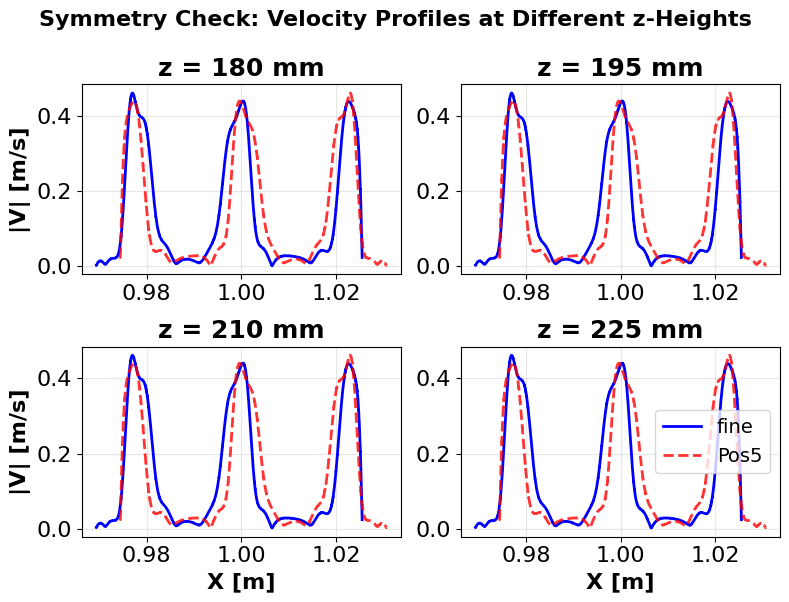


Symmetry check line plots saved!


In [59]:
#SYMMETRY CHECK
# Read both CSV files
sym_df1 = pd.read_csv(f'{sym_folder1}/{sym_file1}')
sym_df2 = pd.read_csv(f'{sym_folder2}/{sym_file2}')

print(f"Loaded File 1: {sym_file1} - {sym_df1.shape[0]} points")
print(f"Loaded File 2: {sym_file2} - {sym_df2.shape[0]} points")

# Map column names to standard format if needed
header_mapping = {
    'x': 'Points_0', 'x ': 'Points_0',
    'y': 'Points_1', 'y ': 'Points_1',
    'z': 'Points_2', 'z ': 'Points_2',
    'Vel_u': 'av_u_0', 'Vel_v': 'av_u_1', 'Vel_w': 'av_u_2',
    'Vel_mag': 'av_u_Magnitude'
}
sym_df1 = sym_df1.rename(columns=header_mapping)
sym_df2 = sym_df2.rename(columns=header_mapping)

# Calculate velocity magnitude for both
sym_df1['vel_cal'] = np.sqrt(sym_df1['av_u_0']**2 + sym_df1['av_u_2']**2)
sym_df2['vel_cal'] = np.sqrt(sym_df2['av_u_0']**2 + sym_df2['av_u_2']**2)

# Flip the second file horizontally (across X axis - mirror left/right)
# This mirrors the X coordinates around the center
x_center = (sym_df2['Points_0'].max() + sym_df2['Points_0'].min()) / 2
sym_df2_flipped = sym_df2.copy()
sym_df2_flipped['Points_0'] = 2 * x_center - sym_df2['Points_0']
# Also flip the X-velocity component (direction reverses)
sym_df2_flipped['av_u_0'] = -sym_df2['av_u_0']
# Recalculate velocity magnitude after flipping
sym_df2_flipped['vel_cal'] = np.sqrt(sym_df2_flipped['av_u_0']**2 + sym_df2_flipped['av_u_2']**2)

print(f"\nFlipped File 2 horizontally around X = {x_center:.6f} m")

# Generate z-values for line plots
z_values_sym = np.arange(z_min_sym, z_max_sym + 1e-12, z_step_sym)
#print(f"\nGenerating line plots from z = {z_min_sym*1000:.3f} mm to {z_max_sym*1000:.3f} mm")
#print(f"Step size: {z_step_sym*1000:.3f} mm")
#print(f"Total number of plots: {len(z_values_sym)}")

# Store data for each z-height
stored_sym_data = []

for z_target in z_values_sym:
    deci = 5
    
    # Find closest z-value in each dataset
    closest_z_df1 = sym_df1['Points_2'].iloc[(sym_df1['Points_2'] - z_target).abs().argsort()[:1]].iloc[0]
    closest_z_df2 = sym_df2_flipped['Points_2'].iloc[(sym_df2_flipped['Points_2'] - z_target).abs().argsort()[:1]].iloc[0]
    
    #print(f"Target z = {z_target*1000:.1f} mm: File1 z = {closest_z_df1*1000:.3f} mm, File2 z = {closest_z_df2*1000:.3f} mm")
    
    # Filter the data for these closest z values with small tolerance
    sym_df1_filtered = sym_df1[abs(sym_df1['Points_2'] - closest_z_df1) < 10**(-deci)]
    sym_df2_filtered = sym_df2_flipped[abs(sym_df2_flipped['Points_2'] - closest_z_df2) < 10**(-deci)]
    
    # Sort the filtered data by the x-axis for proper plotting
    sym_df1_filtered = sym_df1_filtered.sort_values('Points_0')
    sym_df2_filtered = sym_df2_filtered.sort_values('Points_0')
    
    # Calculate velocity magnitude
    magnitude_sym1 = np.sqrt(sym_df1_filtered['av_u_0']**2 + sym_df1_filtered['av_u_2']**2)
    magnitude_sym2 = np.sqrt(sym_df2_filtered['av_u_0']**2 + sym_df2_filtered['av_u_2']**2)
    
    # Store data for subplot
    stored_sym_data.append({
        'z_target_mm': z_target * 1000,
        'z_file1': closest_z_df1 * 1000,
        'z_file2': closest_z_df2 * 1000,
        'x_file1': sym_df1_filtered['Points_0'].values,
        'vel_file1': magnitude_sym1.values,
        'x_file2': sym_df2_filtered['Points_0'].values,
        'vel_file2': magnitude_sym2.values,
    })

# Create adaptive summary subplot
total_sym_plots = len(stored_sym_data)
if total_sym_plots <= 4:
    n_rows, n_cols = 2, 2
    selected_indices = list(range(total_sym_plots))
elif total_sym_plots <= 9:
    n_rows, n_cols = 3, 3
    selected_indices = list(range(total_sym_plots))
elif total_sym_plots <= 16:
    n_rows, n_cols = 4, 4
    selected_indices = list(range(total_sym_plots))
else:
    n_rows, n_cols = 5, 5
    step = max(1, total_sym_plots // 25)
    selected_indices = list(range(0, total_sym_plots, step))[:25]

# Ensure we have the right number of plots
n_subplots = n_rows * n_cols
selected_indices = selected_indices[:n_subplots]

#print(f"\nCreating summary subplot with {len(selected_indices)} plots ({n_rows}x{n_cols} grid)")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

for i, idx in enumerate(selected_indices):
    data = stored_sym_data[idx]
    ax = axes[i]
    
    # Plot File 1
    ax.plot(data['x_file1'], data['vel_file1'], label=file1_label, 
            color='b', linestyle='-', linewidth=2, zorder=2)
    
    # Plot File 2 (Flipped)
    ax.plot(data['x_file2'], data['vel_file2'], label=file2_label, 
            color='r', linestyle='--', linewidth=2, zorder=3, alpha=0.8)
    
    if i >= len(selected_indices) - n_cols:
        ax.set_xlabel('X [m]', fontsize=16, fontweight='bold')
    if i % n_cols == 0:
        ax.set_ylabel('|V| [m/s]', fontsize=16, fontweight='bold')
    
    ax.tick_params(labelsize=16)
    ax.set_title(f'z = {data["z_target_mm"]:.0f} mm', fontsize=18, fontweight='bold')
    ax.grid(True, alpha=0.3)
    

# Hide unused subplots
for i in range(len(selected_indices), len(axes)):
    axes[i].set_visible(False)

# Add legend only to the last pair
if len(selected_indices) > 0:
    axes[len(selected_indices)-1].legend(fontsize=14, loc='best', frameon=True)

plt.suptitle(f'Symmetry Check: Velocity Profiles at Different z-Heights', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{output_dir}/Symmetry_Check_Line_Profiles_pos{pos}.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSymmetry check line plots saved!")

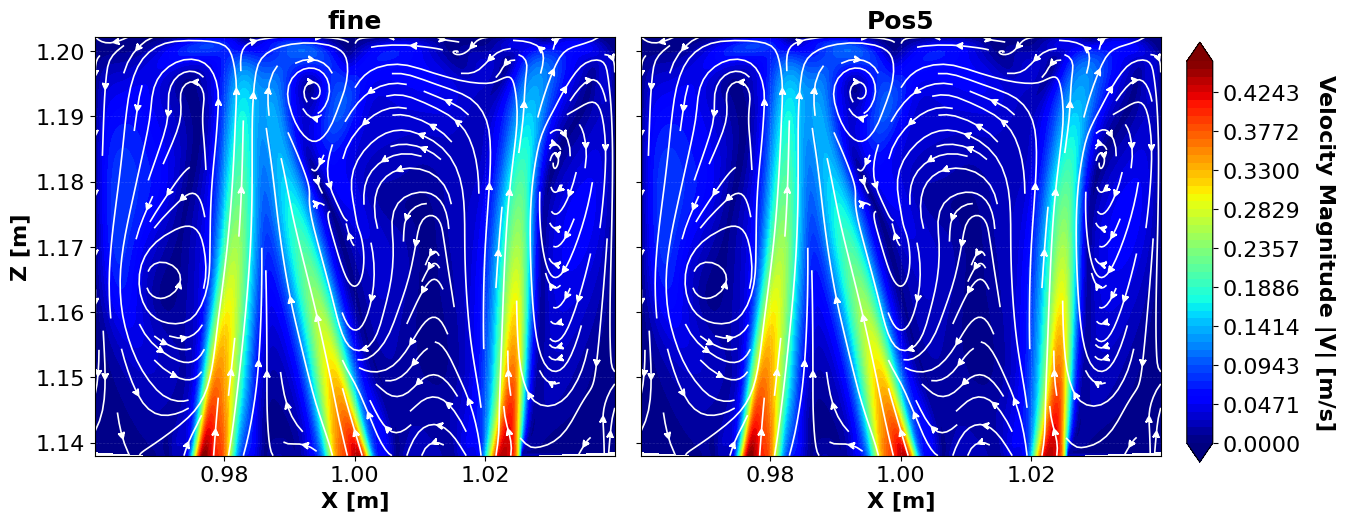

In [60]:
# Contour plot for symmetry check: Pos 3 vs Pos 5 (flipped)
df1_plot = sym_df1.dropna(subset=['Points_0', 'Points_2', 'vel_cal']).copy()
df2_plot = sym_df2.dropna(subset=['Points_0', 'Points_2', 'vel_cal']).copy()

# Common overlapping domain
x_min_plot = max(df1_plot['Points_0'].min(), df2_plot['Points_0'].min())
x_max_plot = min(df1_plot['Points_0'].max(), df2_plot['Points_0'].max())
z_min_plot = max(df1_plot['Points_2'].min(), df2_plot['Points_2'].min())
z_max_plot = min(df1_plot['Points_2'].max(), df2_plot['Points_2'].max())
common_bounds_sym = (x_min_plot, x_max_plot, z_min_plot, z_max_plot)

# Common color scale
vmin_plot = min(df1_plot['vel_cal'].min(), df2_plot['vel_cal'].min())
vmax_plot = max(df1_plot['vel_cal'].max(), df2_plot['vel_cal'].max())
levels_plot = np.linspace(vmin_plot, vmax_plot, 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# Streamline grids
x1_points = np.linspace(common_bounds_sym[0], common_bounds_sym[1], n_arrows)
z1_points = np.linspace(common_bounds_sym[2], common_bounds_sym[3], n_arrows)
X1, Z1 = np.meshgrid(x1_points, z1_points)

points1 = np.column_stack((df1_plot['Points_0'].values, df1_plot['Points_2'].values))
U1 = griddata(points1, df1_plot['av_u_0'].values, (X1, Z1), method='linear', fill_value=0)
V1 = griddata(points1, df1_plot['av_u_2'].values, (X1, Z1), method='linear', fill_value=0)

m1 = np.sqrt(U1**2 + V1**2)
mask1 = m1 > 1e-6
U1_norm = np.zeros_like(U1)
V1_norm = np.zeros_like(V1)
U1_norm[mask1] = U1[mask1] / m1[mask1]
V1_norm[mask1] = V1[mask1] / m1[mask1]

x2_points = np.linspace(common_bounds_sym[0], common_bounds_sym[1], n_arrows)
z2_points = np.linspace(common_bounds_sym[2], common_bounds_sym[3], n_arrows)
X2, Z2 = np.meshgrid(x2_points, z2_points)

points2 = np.column_stack((df2_plot['Points_0'].values, df2_plot['Points_2'].values))
U2 = griddata(points2, df2_plot['av_u_0'].values, (X2, Z2), method='linear', fill_value=0)
V2 = griddata(points2, df2_plot['av_u_2'].values, (X2, Z2), method='linear', fill_value=0)

m2 = np.sqrt(U2**2 + V2**2)
mask2 = m2 > 1e-6
U2_norm = np.zeros_like(U2)
V2_norm = np.zeros_like(V2)
U2_norm[mask2] = U2[mask2] / m2[mask2]
V2_norm[mask2] = V2[mask2] / m2[mask2]

# Left: Pos 3
contour1 = ax1.tricontourf(
    df1_plot['Points_0'].values, df1_plot['Points_2'].values, df1_plot['vel_cal'].values,
    levels=levels_plot, cmap='jet', vmin=vmin_plot, vmax=vmax_plot, extend='both'
)
ax1.streamplot(X1, Z1, U1_norm, V1_norm, density=1.2, color='white',
               linewidth=1.2, arrowsize=1.0, arrowstyle='fancy')

# Right: Pos 5 
contour2 = ax2.tricontourf(
    df2_plot['Points_0'].values, df2_plot['Points_2'].values, df2_plot['vel_cal'].values,
    levels=levels_plot, cmap='jet', vmin=vmin_plot, vmax=vmax_plot, extend='both'
)
ax2.streamplot(X2, Z2, U2_norm, V2_norm, density=1.2, color='white',
               linewidth=1.2, arrowsize=1.0, arrowstyle='fancy')

# Axes formatting
for ax in (ax1, ax2):
    ax.set_xlabel('X [m]', fontsize=16, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.15, color='white', linewidth=0.5)
    ax.tick_params(axis='x', which='both', labelsize=16)
    ax.tick_params(axis='y', which='both', labelsize=16)
    ax.set_xlim(common_bounds_sym[0], common_bounds_sym[1])
    ax.set_ylim(common_bounds_sym[2], common_bounds_sym[3])
    ax2.tick_params(axis='y', which='major', labelleft=False)

ax1.set_ylabel('Z [m]', fontsize=16, fontweight='bold')

ax1.set_title(f'{file1_label}', fontsize=18, fontweight='bold')
ax2.set_title(f'{file2_label}', fontsize=18, fontweight='bold')

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(contour1, cax=cbar_ax)
cbar.set_label('Velocity Magnitude |V| [m/s]', rotation=270, labelpad=25,
               fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=16)

plt.subplots_adjust(left=0.08, right=0.90, top=0.90, bottom=0.12, wspace=0.05)
plt.savefig(f'{output_dir}/Symmetry_Contour_Pos{file1_label}.png', dpi=300, bbox_inches='tight')
plt.show()

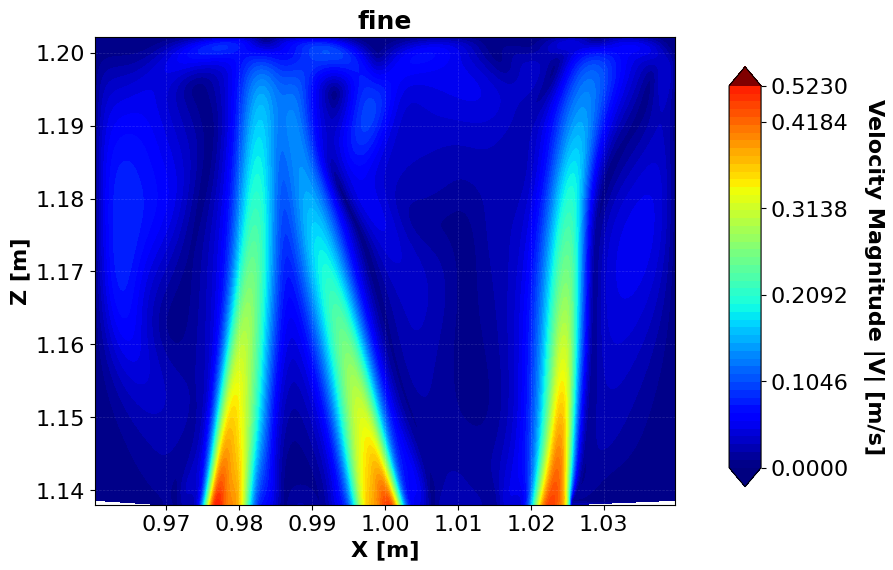

In [61]:
fig, ax = plt.subplots(figsize=(8, 6))

contour1 = ax.tricontourf(
    df1_plot['Points_0'].values, df1_plot['Points_2'].values, df1_plot['vel_cal'].values,
    levels=levels_plot, cmap='jet', vmin=vmin_plot, vmax=vmax_plot, extend='both'
)
#ax.streamplot(X1, Z1, U1_norm, V1_norm, density=1.2, color='white',
#              linewidth=1.2, arrowsize=1.0, arrowstyle='fancy')

# Axes formatting
ax.set_xlabel('X [m]', fontsize=16, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.15, color='white', linewidth=0.5)
ax.tick_params(axis='x', which='both', labelsize=16)
ax.tick_params(axis='y', which='both', labelsize=16)
ax.set_xlim(common_bounds_sym[0], common_bounds_sym[1])
ax.set_ylim(common_bounds_sym[2], common_bounds_sym[3])
ax.set_ylabel('Z [m]', fontsize=16, fontweight='bold')
ax.set_title(f'{file1_label}', fontsize=18, fontweight='bold')

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.04, 0.7]) #[]
contour1.set_clim(0.0, 0.52289)
cbar = fig.colorbar(contour1, cax=cbar_ax)
cbar.set_ticks(np.linspace(0.0, 0.523, 6))
cbar.set_label('Velocity Magnitude |V| [m/s]', rotation=270, labelpad=25,
               fontsize=16, fontweight='bold')
cbar.ax.tick_params(labelsize=16)

plt.subplots_adjust(left=0.08, right=0.90, top=0.90, bottom=0.12, wspace=0.05)
plt.savefig(f'{output_dir}/grid_{file1_label}.png', dpi=300, bbox_inches='tight')
plt.show()

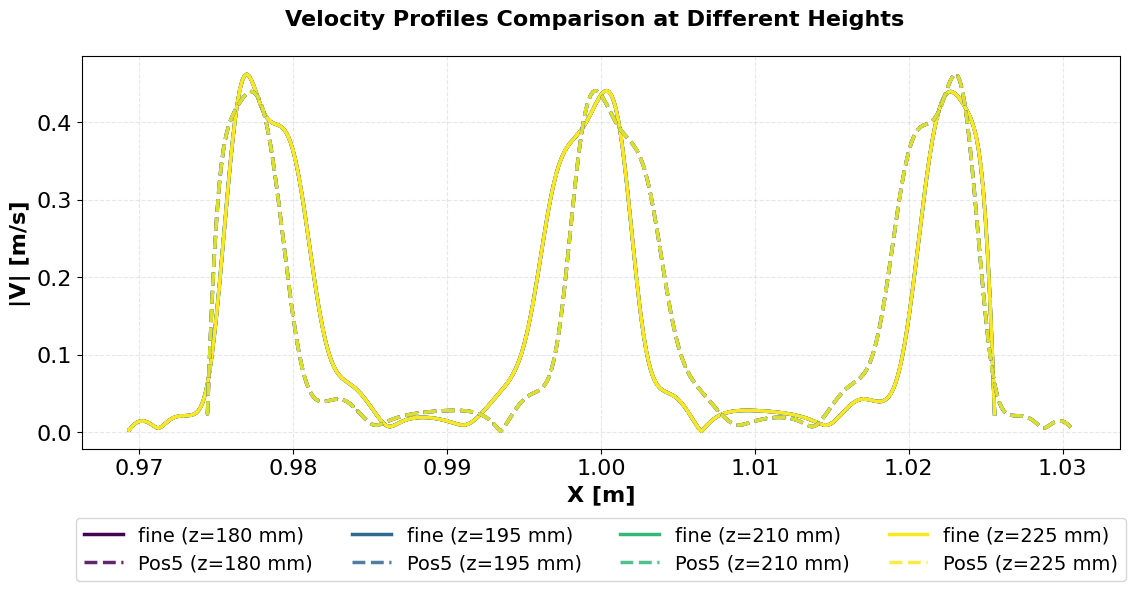

In [62]:
# Create a single plot combining all line plots with position labels
fig, ax = plt.subplots(figsize=(12, 6))
data = stored_sym_data[idx]

colors = plt.cm.viridis(np.linspace(0, 1, len(selected_indices)))

for i, idx in enumerate(selected_indices):
        data = stored_sym_data[idx]
        color = colors[i]

        ax.plot(
                data['x_file1'], data['vel_file1'],
                label=file1_label + f' (z={data["z_target_mm"]:.0f} mm)',
                color=color, linestyle='-', linewidth=2.5, zorder=2
        )

        ax.plot(
                data['x_file2'], data['vel_file2'],
                label=file2_label + f' (z={data["z_target_mm"]:.0f} mm)',
                color=color, linestyle='--', linewidth=2.5, zorder=3, alpha=0.85
        )

ax.set_xlabel('X [m]', fontsize=16, fontweight='bold')
ax.set_ylabel('|V| [m/s]', fontsize=16, fontweight='bold')
ax.legend(fontsize=14, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=True)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(labelsize=16)


plt.suptitle(f'Velocity Profiles Comparison at Different Heights', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{output_dir}/Combined_Line_Profiles_Pos{pos}.png', dpi=300, bbox_inches='tight')
plt.show()

In [63]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

# 2D difference plot: sym_df1 vs flipped sym_df2
# ABSOLUTE RELATIVE ERROR in velocity magnitude on the X-Z plane,
# with projected particle edges overlaid.

# Clean data
df_a = sym_df1.dropna(subset=['Points_0', 'Points_2', 'vel_cal']).copy()
df_b = sym_df2_flipped.dropna(subset=['Points_0', 'Points_2', 'vel_cal']).copy()

# Common grid over the overlapping domain
x_grid = np.linspace(x_min_common, x_max_common, 300)
z_grid = np.linspace(z_min_sym, z_max_sym, 150)
Xg, Zg = np.meshgrid(x_grid, z_grid)

# Interpolate both fields onto the same grid
points_a = np.column_stack((df_a['Points_0'].values, df_a['Points_2'].values))
points_b = np.column_stack((df_b['Points_0'].values, df_b['Points_2'].values))

vel_a = griddata(points_a, df_a['vel_cal'].values, (Xg, Zg), method='linear')
vel_b = griddata(points_b, df_b['vel_cal'].values, (Xg, Zg), method='linear')

# Normalized error [%]  (U_ref = global peak |V|, avoids blow-up near zero)
U_ref = np.nanmax([np.nanmax(np.abs(vel_a)), np.nanmax(np.abs(vel_b))])
err_pct = np.abs(vel_b - vel_a) / U_ref * 100.0

# Geometry mask: fluid where both fields are defined
fluid_mask = np.isfinite(vel_a) & np.isfinite(vel_b)

# Summary statistics
mean_error_pct = np.nanmean(err_pct[fluid_mask])
max_error_pct  = np.nanmax(err_pct[fluid_mask])
print(f"Mean absolute error: {mean_error_pct:.3f}%")
print(f"Max  absolute error: {max_error_pct:.3f}%")

# ── Figure ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

vmax = max_error_pct * 1.05
cf = ax.pcolormesh(
    Xg * 1e3, Zg * 1e3, err_pct,
    cmap='Reds', shading='gouraud', vmin=0, vmax=vmax
)

# Stats annotation (top-left corner)
ax.text(0.015, 0.97,
        f'Mean: {mean_error_pct:.2f}%\nMax:  {max_error_pct:.2f}%',
        transform=ax.transAxes, va='top', fontsize=16,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#555555', alpha=0.88))

# Colorbar (right side, vertical)
cbar = fig.colorbar(cf, ax=ax, pad=0.015, shrink=0.92)
cbar.set_label(r'$|\Delta V|\,/\,U_\mathrm{ref}$  [%]', fontsize=16, labelpad=10)
_dec = 0 if vmax >= 10 else (1 if vmax >= 2 else 2)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.{_dec}f}%"))
cbar.ax.tick_params(labelsize=16)
cbar.outline.set_linewidth(1)

ax.set_xlabel('X  [mm]', fontsize=16, fontweight='bold')
ax.set_ylabel('Z  [mm]', fontsize=16, fontweight='bold')
ax.set_title(r'Numerical symmetry residual-30°, Re$_p$ = 300',
             fontsize=18, fontweight='bold')
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
ax.tick_params(labelsize=16)

plt.tight_layout()
plt.savefig(f'{output_dir}/Symmetry_2D_ErrorMap_pos{pos}.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3765282/1090630009.py:25: RuntimeWarning: All-NaN slice encountered
  U_ref = np.nanmax([np.nanmax(np.abs(vel_a)), np.nanmax(np.abs(vel_b))])
/tmp/ipykernel_3765282/1090630009.py:25: RuntimeWarning: All-NaN axis encountered
  U_ref = np.nanmax([np.nanmax(np.abs(vel_a)), np.nanmax(np.abs(vel_b))])
/tmp/ipykernel_3765282/1090630009.py:32: RuntimeWarning: Mean of empty slice
  mean_error_pct = np.nanmean(err_pct[fluid_mask])


ValueError: zero-size array to reduction operation fmax which has no identity

In [ ]:
if 'err_pct' not in globals():
    raise NameError("err_pct is not available. Run the 2D difference plot cell first.")

abs_err_pct = np.abs(err_pct)

mean_error_pct = np.nanmean(abs_err_pct)
max_error_pct = np.nanmax(abs_err_pct)

print(f"Mean absolute error: {mean_error_pct:.3f}%")
print(f"Max absolute error:  {max_error_pct:.3f}%")